# Per-game anomaly summary — men's World Cups
For every men's World Cup game, whether the **game-window mean WBGT** sits above the 75th / 90th / 95th percentile (or the record) of the stadium × day-of-year (±7 d) **1960–1990** climatology. **Left:** composition per tournament (within band / above the percentile / a new record). **Right:** absolute in-play peak WBGT (game-window max) by year, with trend. Three versions are produced (75 %, 90 %, 95 %).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# set ROOT to the bundle path if you move this notebook
ROOT = "/glade/derecho/scratch/gavinmad/shared/Heathack"
PROC = os.path.join(ROOT, "data", "processed")
plt.rcParams.update({"font.size": 13, "figure.dpi": 120})
from scipy import stats
DF = {g: pd.read_csv(os.path.join(PROC, f"pergame_anomaly_summary_{g}.csv")) for g in ["men", "women"]}
{g: len(v) for g, v in DF.items()}

{'men': 911, 'women': 348}

/glade/derecho/scratch/gavinmad/tmp/ipykernel_87814/4115958032.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/03_climatology/pergame_anomaly_summary_men_p75.png


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/03_climatology/pergame_anomaly_summary_women_left_p75.png


/glade/derecho/scratch/gavinmad/tmp/ipykernel_87814/4115958032.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/03_climatology/pergame_anomaly_summary_men_p90.png


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/03_climatology/pergame_anomaly_summary_women_left_p90.png


/glade/derecho/scratch/gavinmad/tmp/ipykernel_87814/4115958032.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/03_climatology/pergame_anomaly_summary_men_p95.png


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/03_climatology/pergame_anomaly_summary_women_left_p95.png


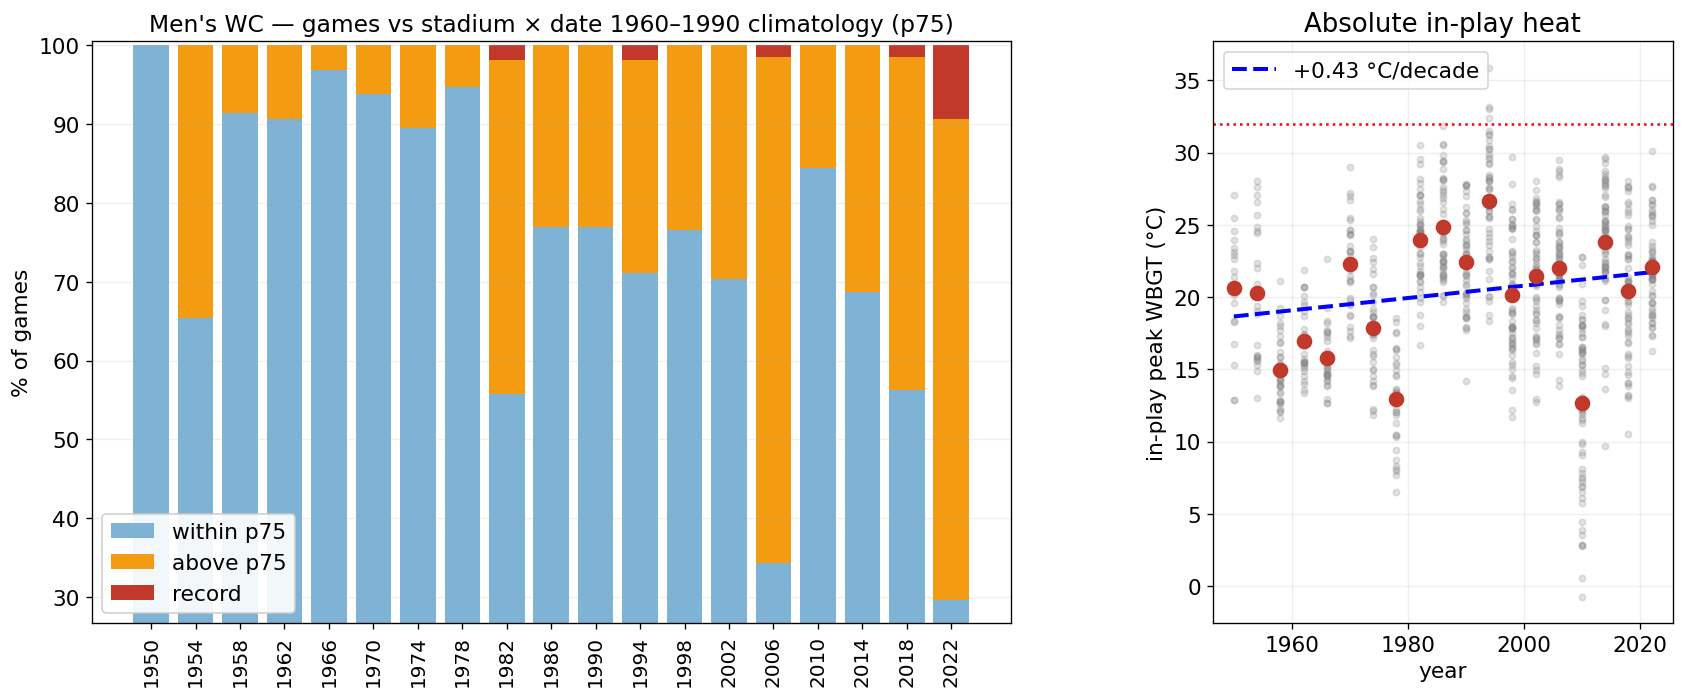

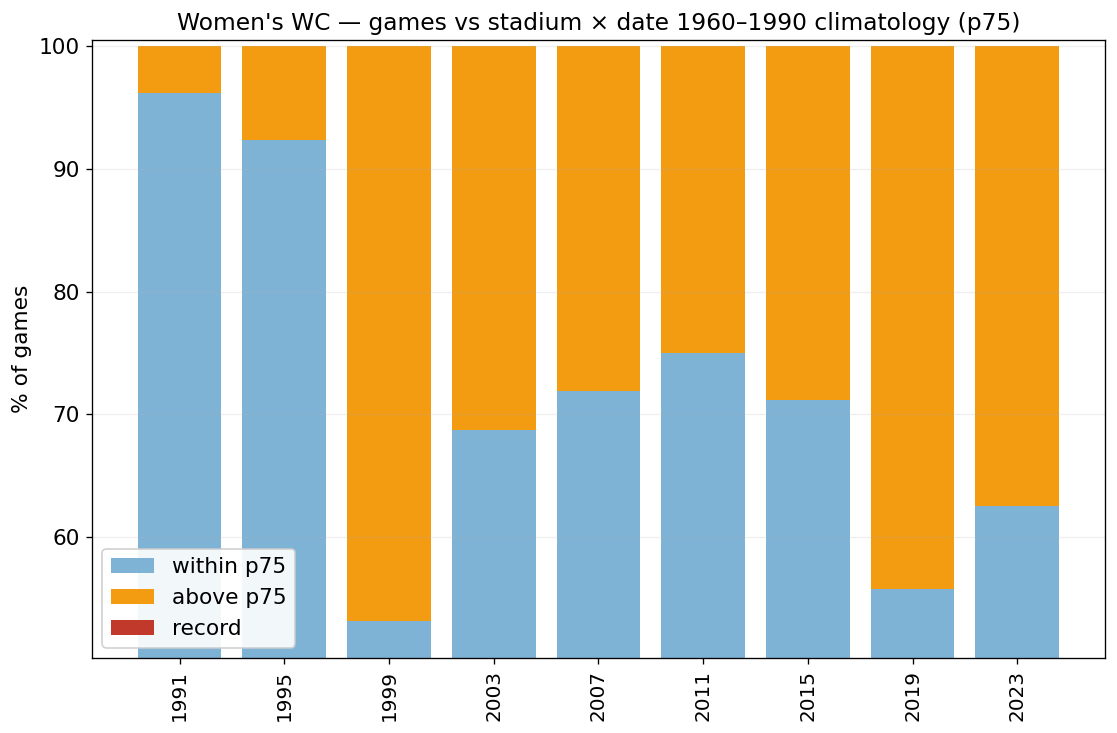

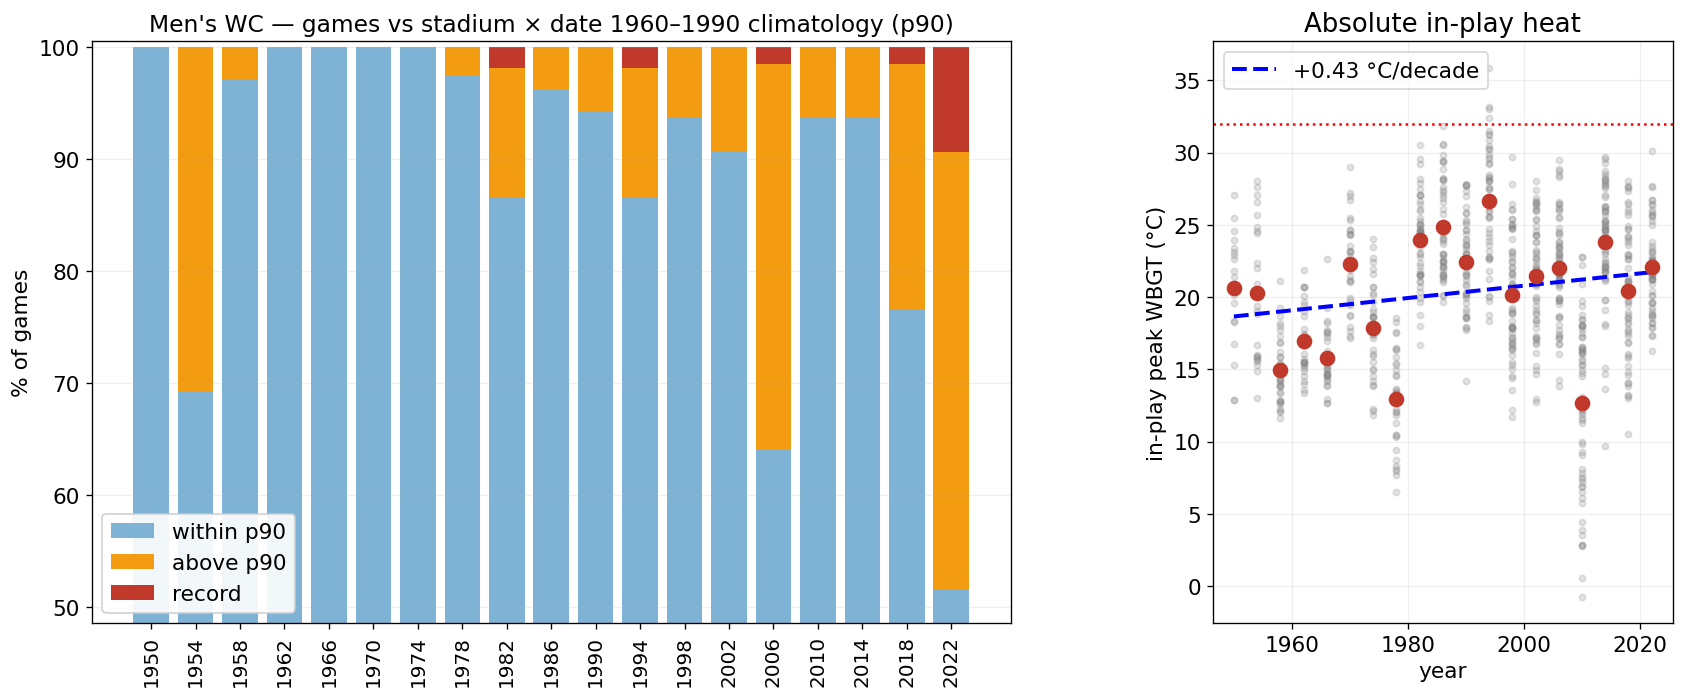

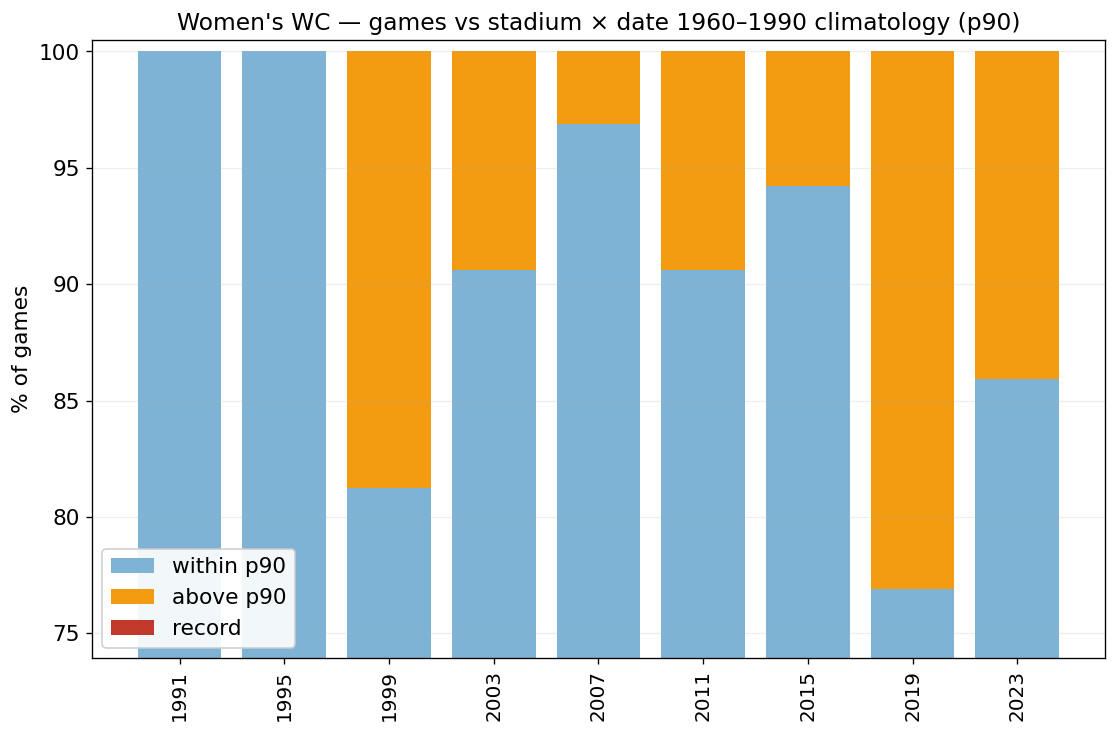

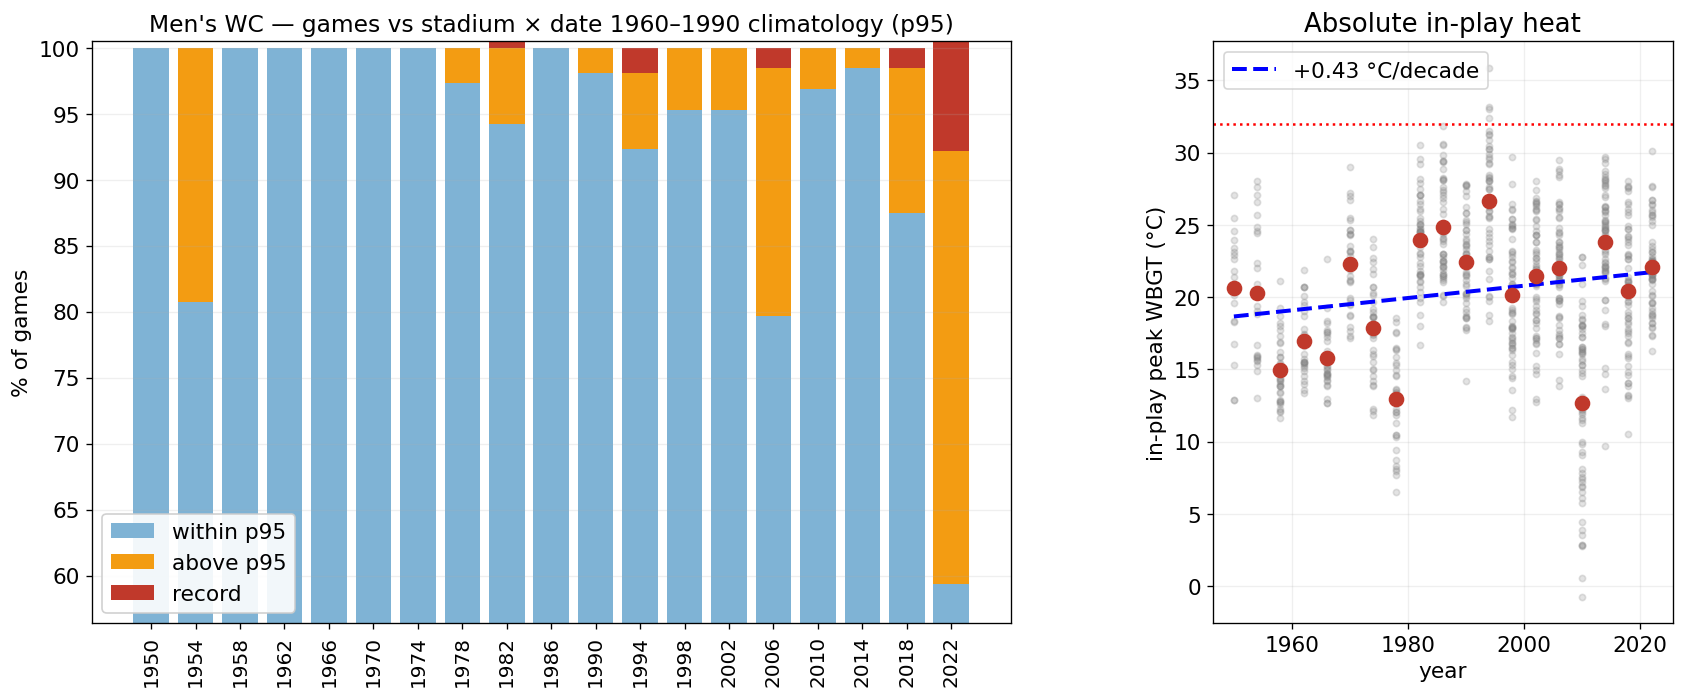

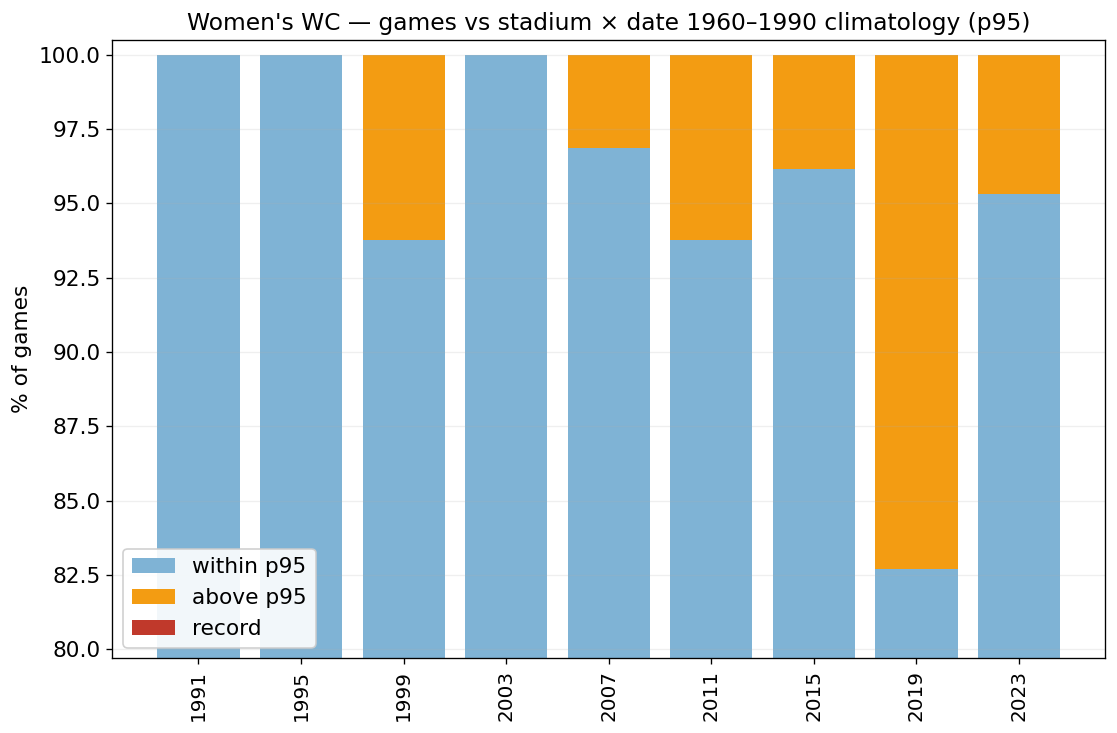

In [2]:
def make_summary(gender, level, panels="both", save=True):
    d = DF[gender]; yrs = sorted(d.year.unique())
    flag = f"above_p{level}"
    within = [100*((d.year==y)&(~d[flag])).sum()/(d.year==y).sum() for y in yrs]
    above  = [100*((d.year==y)&d[flag]&(~d.above_record)).sum()/(d.year==y).sum() for y in yrs]
    rec    = [100*((d.year==y)&d.above_record).sum()/(d.year==y).sum() for y in yrs]
    x = np.arange(len(yrs))
    if panels == "left":
        fig, axA = plt.subplots(figsize=(9.5, 6.3))
    else:
        fig = plt.figure(figsize=(17, 6.3)); gs = fig.add_gridspec(1, 3, width_ratios=[2, 0, 1], wspace=0.22)
        axA = fig.add_subplot(gs[0, 0]); axB = fig.add_subplot(gs[0, 2])
    axA.bar(x, within, color="#7fb3d5", label=f"within p{level}")
    axA.bar(x, above, bottom=within, color="#f39c12", label=f"above p{level}")
    axA.bar(x, rec, bottom=np.array(within)+np.array(above), color="#c0392b", label="record")
    axA.set_xticks(x); axA.set_xticklabels(yrs, rotation=90, fontsize=12)
    axA.set_ylim(min(within)-3, 100.5); axA.set_ylabel("% of games")
    axA.set_title(f"{gender.title()}'s WC — games vs stadium × date 1960–1990 climatology (p{level})", fontsize=14)
    axA.legend(loc="lower left", fontsize=13, framealpha=0.9); axA.grid(alpha=0.2, axis="y")
    if panels == "both":
        axB.scatter(d.year, d.gw_wbgt_max, s=14, alpha=0.22, color="grey")
        tm = d.groupby("year").gw_wbgt_max.mean(); axB.scatter(tm.index, tm.values, s=70, color="#c0392b", zorder=6)
        sl, ic, r, p, _ = stats.linregress(d.year, d.gw_wbgt_max)
        axB.plot([d.year.min(), d.year.max()], ic+sl*np.array([d.year.min(), d.year.max()]), "b--", lw=2.4,
                 label=f"{sl*10:+.2f} °C/decade"); axB.axhline(32, color="red", ls=":", lw=1.5)
        axB.set_ylabel("in-play peak WBGT (°C)"); axB.set_xlabel("year"); axB.set_title("Absolute in-play heat")
        axB.legend(fontsize=13, loc="upper left"); axB.grid(alpha=0.2)
    fig.tight_layout()
    suffix = "_left" if panels == "left" else ""
    if save:
        out = os.path.join(ROOT, f"figures/03_climatology/pergame_anomaly_summary_{gender}{suffix}_p{level}.png")
        fig.savefig(out, dpi=200, bbox_inches="tight"); print("wrote", out)
    return fig

for lv in [75, 90, 95]:
    make_summary("men", lv, panels="both")       # men: full two-panel
    make_summary("women", lv, panels="left")     # women: climatology-relative LEFT panel only